# MLP feature experiment

Reads `keypoints.npz` from `extract_keypoints.ipynb`. Set `FEATURES` in the
vector cell, run top to bottom, and the test cell writes `runs/<mode>.npz`
for `experiments.ipynb`.

train (321697, 21, 3)  val (80086, 21, 3)   26 classes

row 201798  Q  deg -179.98
  kp    node  5  (+0.1535, +0.0307) -> (-0.1535, -0.0307)   dist 0.1566 -> 0.1566   angle  +11.29 -> -168.69   turned -179.98
  kp    node 12  (-0.0459, -0.0456) -> (+0.0459, +0.0456)   dist 0.0647 -> 0.0647   angle -135.23 ->  +44.79   turned -179.98
  world node  5  (+0.0435, +0.0699) -> (-0.0435, -0.0699)   dist 0.0823 -> 0.0823   angle  +58.11 -> -121.87   turned -179.98
  world node 12  (-0.4433, -0.2554) -> (+0.4432, +0.2555)   dist 0.5116 -> 0.5116   angle -150.06 ->  +29.96   turned -179.98

row 248209  U  deg -3.36
  kp    node  5  (+0.0882, -0.0632) -> (+0.0843, -0.0682)   dist 0.1085 -> 0.1085   angle  -35.62 ->  -38.98   turned -3.36
  kp    node 12  (+0.0149, -0.3502) -> (-0.0057, -0.3505)   dist 0.3505 -> 0.3505   angle  -87.57 ->  -90.93   turned -3.36
  world node  5  (+0.3304, -0.0825) -> (+0.3250, -0.1017)   dist 0.3406 -> 0.3406   angle  -14.02 ->  -17.38   turned -3.36
  world node 12

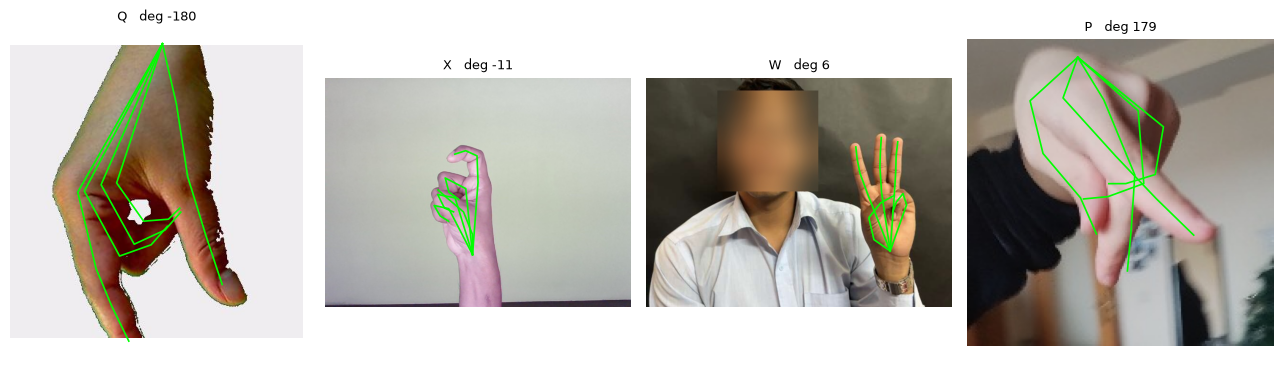

In [1]:
# --- Cached landmarks, turned back to the pose the hand was held in ----------------
# The palm detector spun every crop by deg to stand its hand up, so the cached
# landmarks lost that pose; turning them back by deg puts it into the numbers.
# kp is a fraction of the crop, so it turns about the crop centre. world shares the
# crop's axes and turns about its own origin, which by linearity is the same as
# turning the wrist-relative offsets the cells below build. z is the rotation axis
# in both and is left alone. Train and val only; test is dealt with further down.
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

KEYPOINTS = Path("keypoints.npz")   # written by extract_keypoints.ipynb
FINGERS = [(0, 1, 2, 3, 4), (0, 5, 6, 7, 8), (0, 9, 10, 11, 12),
           (0, 13, 14, 15, 16), (0, 17, 18, 19, 20)]

_z = np.load(KEYPOINTS)
CLASSES = [str(c) for c in _z["classes"]]
train_presence, train_handed, train_labels, train_deg = (
    _z["train_presence"], _z["train_handed"], _z["train_labels"], _z["train_deg"])
val_presence, val_handed, val_labels, val_deg = (
    _z["val_presence"], _z["val_handed"], _z["val_labels"], _z["val_deg"])


def unrotate(split):
    """Cached kp, world -> the same hands at the tilt they had in the source image."""
    kp, world = _z[f"{split}_kp"].copy(), _z[f"{split}_world"].copy()
    rad = np.radians(_z[f"{split}_deg"])
    c, s = np.cos(rad), np.sin(rad)
    turn = np.stack([np.stack([c, -s], -1), np.stack([s, c], -1)], -2)
    kp[..., :2] = 0.5 + np.einsum("nij,nkj->nki", turn, kp[..., :2] - 0.5)
    world[..., :2] = np.einsum("nij,nkj->nki", turn, world[..., :2])
    return kp, world


train_kp, train_world = unrotate("train")
val_kp, val_world = unrotate("val")
print(f"train {train_kp.shape}  val {val_kp.shape}   {len(CLASSES)} classes")


# --- Read the turn off the numbers -------------------------------------------------
# Polar form takes no trigonometry to check: a turn leaves every landmark the same
# distance from the centre it turns about, and advances every angle by the same deg.
# kp measures from the crop centre 0.5, world from its own origin. Printed below are
# the index knuckle and the middle fingertip on three rows spanning the range of deg.
def polar(v):
    """(x, y) offsets -> how far out each point sits, and at what angle."""
    return np.linalg.norm(v, axis=-1), np.degrees(np.arctan2(v[..., 1], v[..., 0]))


for _row in np.argsort(train_deg)[np.linspace(0, len(train_kp) - 1, 3).astype(int)]:
    print(f"\nrow {_row}  {CLASSES[train_labels[_row]]}  deg {train_deg[_row]:+.2f}")
    for _name, _was, _now in (
            ("kp   ", _z["train_kp"][_row, :, :2] - 0.5, train_kp[_row, :, :2] - 0.5),
            ("world", _z["train_world"][_row, :, :2], train_world[_row, :, :2])):
        (_r0, _a0), (_r1, _a1) = polar(_was), polar(_now)
        for _n in (5, 12):
            print(f"  {_name} node {_n:2d}  "
                  f"({_was[_n, 0]:+.4f}, {_was[_n, 1]:+.4f}) -> "
                  f"({_now[_n, 0]:+.4f}, {_now[_n, 1]:+.4f})   "
                  f"dist {_r0[_n]:.4f} -> {_r1[_n]:.4f}   "
                  f"angle {_a0[_n]:+7.2f} -> {_a1[_n]:+7.2f}   "
                  f"turned {(_a1[_n] - _a0[_n] + 180) % 360 - 180:+.2f}")

# The same two rules over every train row, not just the twelve lines printed. A point
# sitting almost on the centre is skipped, since its angle is noise at float32.
_was, _now = _z["train_kp"][..., :2] - 0.5, train_kp[..., :2] - 0.5
assert np.allclose(polar(_now)[0], polar(_was)[0], atol=1e-5)
assert np.allclose(polar(train_world[..., :2])[0],
                   polar(_z["train_world"][..., :2])[0], atol=1e-5)
_turned = polar(_now)[1] - polar(_was)[1] - train_deg[:, None]
assert np.abs((_turned + 180) % 360 - 180)[polar(_was)[0] > 0.02].max() < 0.05

# Direction is the one part the numbers cannot settle on their own, since turning the
# wrong way round obeys both rules above just as well. So put the turned landmarks back
# on the source image. roi is (cx, cy, side), so a crop-fraction offset becomes a pixel
# offset from the ROI centre once scaled by side. A skeleton lying along the hand means
# deg was undone the right way round; these four rows span its range.
_rows = np.argsort(train_deg)[np.linspace(0, len(train_kp) - 1, 4).astype(int)]
fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
for ax, row in zip(axes, _rows):
    cx, cy, side = _z["train_roi"][row]
    pts = np.array([cx, cy]) + side * (train_kp[row, :, :2] - 0.5)
    ax.imshow(cv2.cvtColor(cv2.imread(_z["train_paths"][row]), cv2.COLOR_BGR2RGB))
    for finger in FINGERS:
        ax.plot(pts[list(finger), 0], pts[list(finger), 1], "-", lw=1.2, c="lime")
    ax.set_title(f"{CLASSES[train_labels[row]]}   deg {train_deg[row]:.0f}", fontsize=9)
    ax.axis("off")
plt.tight_layout()

In [2]:
# --- Cached landmarks -> the model's input vector ----------------------------------
# Three steps land before the spans, in this order, because each changes what the next
# one sees: the folders that sign a letter facing the wrong way are turned around, then
# left hands are folded onto right, then one span per block puts everything inside
# [0,1] without clipping. Direction is already in the numbers from the cell above, so
# there is no separate direction block any more.
import numpy as np

# "2d"      = image x,y only (42)
# "2.5d"    = image x,y + depth z (63)
# "3d"      = wrist-relative world landmarks (63)
# "2d+3d"   = 42 + 63 (105)
# "2.5d+3d" = 63 + 63 (126)   -- same meaning as config.FEATURES in the repo root
FEATURES = "2d"
FEATURE_DIMS = {"2d": 42, "2.5d": 63, "3d": 63, "2d+3d": 105, "2.5d+3d": 126}
IN_DIM = FEATURE_DIMS[FEATURES]

# Folders that sign these letters end for end. Turning a hand around is a half turn
# about the vertical axis, so x and z both change sign while y stays put -- that keeps
# it the same hand. A mirror, which flips x alone, would turn a right hand into a left.
FACING_LETTERS = "GHPQ"
FACING_FOLDERS = ("2", "4", "6", "9", "10", "12", "16")


def turn_around(kp, world, labels, subset):
    """Half turn about the vertical axis, for the folders that sign GHPQ backwards."""
    folder = np.array([s.split("/")[0] for s in subset])
    hit = (np.isin(labels, [CLASSES.index(c) for c in FACING_LETTERS])
           & np.isin(folder, FACING_FOLDERS))
    kp, world = kp.copy(), world.copy()
    kp[hit, :, 0] = 1.0 - kp[hit, :, 0]     # kp x is a fraction of the crop, so it
    kp[hit, :, 2] *= -1.0                   # turns about 0.5; its z is 0 at the wrist
    world[hit, :, 0] *= -1.0
    world[hit, :, 2] *= -1.0
    return kp, world, hit


def mirror(kp, world, handed):
    """Left hands folded onto right, so one sign is one shape. Only x moves."""
    flip = handed < 0.5
    kp, world = kp.copy(), world.copy()
    kp[flip, :, 0] = 1.0 - kp[flip, :, 0]
    world[flip, :, 0] *= -1.0
    return kp, world


train_y, val_y = train_labels, val_labels
tr_kp, tr_w, tr_hit = turn_around(train_kp, train_world, train_y, _z["train_subset"])
va_kp, va_w, va_hit = turn_around(val_kp, val_world, val_y, _z["val_subset"])
tr_kp, tr_w = mirror(tr_kp, tr_w, train_handed)
va_kp, va_w = mirror(va_kp, va_w, val_handed)
tr_w -= tr_w[:, :1, :]                      # node 0 is the wrist; offsets first,
va_w -= va_w[:, :1, :]                      # then one span over the offsets

span = lambda a, b: (min(a.min(), b.min()), max(a.max(), b.max()))
XY_SPAN = span(tr_kp[..., :2], va_kp[..., :2])
Z_SPAN = span(tr_kp[..., 2], va_kp[..., 2])
W_SPAN = span(tr_w, va_w)
unit = lambda a, s: (a - s[0]) / (s[1] - s[0])


def features(kp, world):
    """-> (N, IN_DIM) in [0,1]. Blocks match config.FEATURES in the repo root."""
    n = len(kp)
    xy = unit(kp[..., :2], XY_SPAN).reshape(n, -1)
    z = unit(kp[..., 2], Z_SPAN).reshape(n, -1)
    w = unit(world, W_SPAN).reshape(n, -1)
    if FEATURES not in FEATURE_DIMS:
        raise ValueError(f"FEATURES must be one of {tuple(FEATURE_DIMS)} (got {FEATURES!r})")
    parts = {"2d": [xy], "2.5d": [xy, z], "3d": [w], "2d+3d": [xy, w],
             "2.5d+3d": [xy, z, w]}[FEATURES]
    return np.concatenate(parts, 1).astype(np.float32)


# main values being used
X_train, X_val = features(tr_kp, tr_w), features(va_kp, va_w)
assert X_train.shape[1] == IN_DIM and X_train.min() >= 0 and X_train.max() <= 1

# Turning is not flipping, and the difference only shows in 3d: a half turn is det +1
# and leaves the hand the same hand, a mirror is det -1 and swaps it for the other one.
# The signed volume at the wrist is that chirality, so it has to survive the turn and
# reverse for exactly the left hands the fold mirrored, and for nothing else.
def _chirality(a):
    u, v, t = a[:, 5] - a[:, 0], a[:, 17] - a[:, 0], a[:, 9] - a[:, 0]
    return np.sign(np.einsum("ni,ni->n", np.cross(u, v), t))


assert np.array_equal(_chirality(tr_w),
                      np.where(train_handed < 0.5, -1, 1) * _chirality(train_world))
# H is the letter whose folders split most cleanly, so once the turned ones are turned
# they must wind the same way round as the ones that were left alone.
_p = tr_kp[:, [0, 5, 9, 13, 17], :2]
_wind = np.sign(sum(_p[:, i, 0] * _p[:, (i + 1) % 5, 1]
                    - _p[:, (i + 1) % 5, 0] * _p[:, i, 1] for i in range(5)))
_h = train_y == CLASSES.index("H")
assert _wind[_h & tr_hit].mean() * _wind[_h & ~tr_hit].mean() > 0, "facing fix inverted"

print(f"FEATURES {FEATURES!r} -> {IN_DIM} dims")
print(f"turned around {tr_hit.sum():,} train and {va_hit.sum():,} val rows "
      f"({', '.join(FACING_LETTERS)} in folders {', '.join(FACING_FOLDERS)})")
print(f"mirrored {np.mean(train_handed < 0.5):.1%} of train (the left hands)")
if FEATURES != "3d":
    print(f"xy    span [{XY_SPAN[0]:8.2f}, {XY_SPAN[1]:8.2f}] of the crop")
if FEATURES in ("2.5d", "2.5d+3d"):
    print(f"z     span [{Z_SPAN[0]:8.2f}, {Z_SPAN[1]:8.2f}] of the crop")
if FEATURES in ("3d", "2d+3d", "2.5d+3d"):
    print(f"world span [{W_SPAN[0]:8.3f}, {W_SPAN[1]:8.3f}] from the wrist")
print(f"X_train {X_train.shape}  X_val {X_val.shape}  "
      f"range [{X_train.min():.2f}, {X_train.max():.2f}]")

FEATURES '2d' -> 42 dims
turned around 12,395 train and 3,056 val rows (G, H, P, Q in folders 2, 4, 6, 9, 10, 12, 16)
mirrored 24.5% of train (the left hands)
xy    span [   -0.16,     1.14] of the crop
X_train (321697, 42)  X_val (80086, 42)  range [0.00, 0.99]


In [3]:
# --- Test capture -> the same input vector, minus the facing fix -------------------
# The test capture signs G, H, P and Q the right way round, so the turn the cell above
# gives those folders must not happen here. The rest is the same road walked with the
# same functions, and deliberately with the same spans: a model is only ever shown the
# scale it was trained at, so the spans stay the train ones and are never remeasured.
test_labels, test_presence, test_handed, test_left, test_palm = (
    _z["test_labels"], _z["test_presence"], _z["test_handed"], _z["test_left"],
    _z["test_palm"])
test_y = test_labels
# The cache gates nothing, so the palm score and the hand-presence score arrive raw
# and the evaluation picks its own thresholds; jazz's own are 0.5 and 0.5. NaN means
# the image would not decode, the one case with no numbers behind it at all.
test_scored = np.isfinite(test_presence)

# Which hand it is can come from the folder, which is the honest answer, or from the
# landmark net, which is the only answer the app will ever have. The net's is used, so
# that a row is folded here exactly as its like was folded in training, and so that a
# handedness mistake costs a mark at test time just as it would on a phone.
te_kp, te_w = unrotate("test")
te_kp, te_w = mirror(te_kp, te_w, test_handed)
te_w -= te_w[:, :1, :]
# Every frame keeps its row and its numbers, however little jazz believed them. Only
# one that would not decode has nothing, and it gets 0.5, the middle of every span and
# so the least informative input there is.
X_test = np.where(test_scored[:, None],
                  np.clip(features(te_kp, te_w), 0.0, 1.0), 0.5).astype(np.float32)

assert X_test.shape == (len(test_y), IN_DIM) and np.isfinite(X_test).all()
# Folder and net are two independent readings of the same thing, so agreement says the
# folders are named the way round they look; swapped folders would score near zero.
# Only the rows jazz would believe are asked, since a palm found at 0.02 confidence
# has no opinion on handedness worth counting.
_jazz = (test_palm >= 0.5) & (test_presence >= 0.5)
_same = (test_left == (test_handed < 0.5))[_jazz]
assert _same.mean() > 0.9, "left/ and right/ look swapped"

print(f"X_test {X_test.shape}   at jazz's 0.5 and 0.5, "
      f"{np.mean(test_palm >= 0.5):.1%} of frames clear the palm and "
      f"{_jazz.mean():.1%} clear both")
print(f"folder and landmark net agree on which hand for {_same.mean():.1%} of those; "
      f"{np.mean((test_handed < 0.5)[_jazz]):.1%} were folded onto right")
print(f"{np.bincount(test_y).min()} frames for every letter; of the worst-served one "
      f"jazz would refuse {np.bincount(test_y[~_jazz]).max()}")

X_test (3744, 42)   at jazz's 0.5 and 0.5, 92.9% of frames clear the palm and 87.3% clear both
folder and landmark net agree on which hand for 94.3% of those; 45.3% were folded onto right
144 frames for every letter; of the worst-served one jazz would refuse 63


In [4]:
X_train[0]

array([0.56645495, 0.67159075, 0.6502028 , 0.6066967 , 0.6939128 ,
       0.53098214, 0.675343  , 0.46942577, 0.6404378 , 0.423942  ,
       0.6015328 , 0.4778509 , 0.58026177, 0.43200615, 0.60914963,
       0.50278723, 0.6132983 , 0.5169065 , 0.5320144 , 0.50058436,
       0.5216982 , 0.45891368, 0.56046134, 0.53975177, 0.5584825 ,
       0.54393566, 0.47084385, 0.5255782 , 0.45651358, 0.47686347,
       0.50044537, 0.5500781 , 0.49981913, 0.5548982 , 0.41162914,
       0.55545586, 0.40381923, 0.5109472 , 0.44696975, 0.5605023 ,
       0.4569574 , 0.5716131 ], dtype=float32)

In [5]:
# --- Classifier: flattened landmarks -> letter ------------------------------------
# One block per hidden layer: Linear, BatchNorm, ReLU, Dropout -- normalising before
# the nonlinearity keeps activations centred where ReLU is informative.
# The head stays a bare Linear because CrossEntropyLoss wants raw logits; normalising
# or dropping them would fight the loss rather than regularise it.
import torch
import torch.nn as nn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
HIDDEN = (256, 128)
DROPOUT = 0.3
LR = 1e-3


def build_mlp(in_dim=IN_DIM, hidden=HIDDEN, n_classes=len(CLASSES), dropout=DROPOUT):
    layers, prev = [], in_dim
    for width in hidden:
        layers += [nn.Linear(prev, width), nn.BatchNorm1d(width),
                   nn.ReLU(), nn.Dropout(dropout)]
        prev = width
    return nn.Sequential(*layers, nn.Linear(prev, n_classes))


model = build_mlp().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

print(model)
print(f"{sum(t.numel() for t in model.parameters()):,} parameters on {DEVICE}  "
      f"({FEATURES!r}, {IN_DIM} dims)")

Sequential(
  (0): Linear(in_features=42, out_features=256, bias=True)
  (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.3, inplace=False)
  (8): Linear(in_features=128, out_features=26, bias=True)
)
48,026 parameters on cuda  ('2d', 42 dims)


/home/thanponmaiseaumsook/kaggle-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
train:   0%|          | 0/200 [00:00<?, ?ep/s]

train:   0%|          | 1/200 [00:12<41:37, 12.55s/ep]

  1  train 0.1862 / 95.17%   val 0.1080 / 96.56%   lr 1.00e-03


train:   1%|          | 2/200 [00:24<40:33, 12.29s/ep]

  2  train 0.0988 / 97.20%   val 0.0597 / 98.29%   lr 1.00e-03


...

 75  train 0.0308 / 99.10%   val 0.0155 / 99.61%   lr 1.25e-04


train:  40%|████      | 80/200 [15:58<24:01, 12.02s/ep]

 80  train 0.0296 / 99.16%   val 0.0154 / 99.62%   lr 6.25e-05


train:  42%|████▏     | 83/200 [16:47<23:40, 12.14s/ep]

early stop at epoch 84 (10 epochs without val improvement)

best val accuracy 99.63%, weights restored from mlp_best.pt


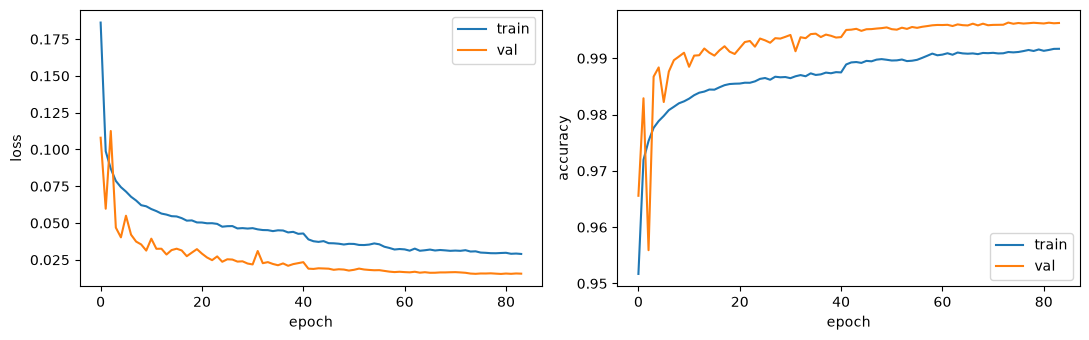

In [6]:
# --- Training ---------------------------------------------------------------------
# The whole split sits on DEVICE; each batch is just an index slice, so there is no
# per-batch host transfer. Val accuracy gates both ReduceLROnPlateau and early
# stopping, so training cuts off once the model stops improving rather than running
# all EPOCHS.
#
# Rerunning this cell continues training the model as it stands. Rerun the classifier
# cell first for a fresh start, otherwise the optimiser state and weights carry over.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.auto import tqdm

BATCH_SIZE = 64
LR_DECAY = 0.5          # multiply lr when val accuracy stalls
LR_PATIENCE = 5          # epochs without improvement before decay
EARLY_STOP = 10          # epochs without improvement before stopping
EPOCHS = 200
MLP_CKPT = Path("mlp_best.pt")  # weights from the best val epoch, rewritten as it improves

assert len(X_train) == len(train_y) and len(X_val) == len(val_y), "rerun the cells above"
assert model[0].in_features == X_train.shape[1], "model predates the current vectors"

X_tr = torch.from_numpy(X_train).to(DEVICE)
y_tr = torch.from_numpy(train_y).to(DEVICE)
X_va = torch.from_numpy(X_val).to(DEVICE)
y_va = torch.from_numpy(val_y).to(DEVICE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=LR_DECAY, patience=LR_PATIENCE)


def run_epoch(X, y, train):
    """One pass over rows already on DEVICE -> mean loss, accuracy."""
    model.train(train)
    n = len(y)
    order = torch.randperm(n, device=DEVICE) if train else torch.arange(n, device=DEVICE)
    if train:                                   # BatchNorm needs more than one row
        order = order[: (n // BATCH_SIZE) * BATCH_SIZE]
    loss_sum = correct = seen = 0.0
    with torch.set_grad_enabled(train):
        for start in range(0, len(order), BATCH_SIZE):
            idx = order[start:start + BATCH_SIZE]
            logits = model(X[idx])
            loss = criterion(logits, y[idx])
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            bs = len(idx)
            loss_sum += loss.detach() * bs
            correct += (logits.argmax(1) == y[idx]).sum()
            seen += bs
    return (loss_sum / seen).item(), (correct / seen).item()


history, best_acc, stale = [], 0.0, 0
for epoch in tqdm(range(1, EPOCHS + 1), desc="train", unit="ep"):
    tr_loss, tr_acc = run_epoch(X_tr, y_tr, True)
    va_loss, va_acc = run_epoch(X_va, y_va, False)
    history.append((tr_loss, tr_acc, va_loss, va_acc))
    scheduler.step(va_acc)
    if va_acc > best_acc:
        best_acc, stale = va_acc, 0
        torch.save(model.state_dict(), MLP_CKPT)
    else:
        stale += 1
    if epoch == 1 or epoch % 5 == 0 or stale == 0:
        lr = optimizer.param_groups[0]["lr"]
        print(f"{epoch:3d}  train {tr_loss:.4f} / {tr_acc:6.2%}   "
              f"val {va_loss:.4f} / {va_acc:6.2%}   lr {lr:.2e}")
    if stale >= EARLY_STOP:
        print(f"early stop at epoch {epoch} ({EARLY_STOP} epochs without val improvement)")
        break

model.load_state_dict(torch.load(MLP_CKPT, map_location=DEVICE))
print(f"\nbest val accuracy {best_acc:.2%}, weights restored from {MLP_CKPT}")

hist = np.array(history)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, col, name in zip(axes, (0, 1), ("loss", "accuracy")):
    ax.plot(hist[:, col], label="train")
    ax.plot(hist[:, col + 2], label="val")
    ax.set_xlabel("epoch")
    ax.set_ylabel(name)
    ax.legend()
plt.tight_layout()

In [7]:
# --- Test: three numbers, one denominator -----------------------------------------
# jazz rejects with `confidence < threshold`, at MediaPipePalmDetector.cs:328 and at
# HandPoseDetectionEngine.cs:255, so a score sitting exactly on the threshold is kept
# and >= is the comparison that matches it. The gates are a chain: presence is only
# ever asked about a frame a palm was found in. Both are quoted out of every frame
# filmed, never out of the survivors of the step before, because a denominator that
# shrinks at each step is what lets a pipeline look accurate by answering less.
from pathlib import Path

import numpy as np
import torch

RUNS_DIR = Path("runs")     # one <FEATURES>.npz per mode, read by experiments.ipynb
PALM_MIN = 0.5              # jazz HandPoseDetector.prefab palmConfidenceThreshold
PRESENCE_MIN = 0.5          # jazz HandPoseDetector.prefab handPoseConfidenceThreshold

found = test_palm >= PALM_MIN
sure = found & (test_presence >= PRESENCE_MIN)

model.eval()
with torch.no_grad():
    pred = model(torch.from_numpy(X_test).to(DEVICE)).argmax(1).cpu().numpy()
# A frame no hand was ever found in cannot be answered correctly, whatever the model
# happens to reply to the filler row standing in for it.
hit = sure & (pred == test_y)

n, each = len(test_y), np.bincount(test_y).min()
assert hit.sum() <= sure.sum() <= found.sum() <= n, "a stage passed on more than it got"

print(f"{n:,} frames, {each} of every letter, left and right")
print(f"  palm found       {found.sum():6,}   {found.mean():7.2%} of all")
print(f"  hand confirmed   {sure.sum():6,}   {sure.mean():7.2%} of all")
print(f"  letter correct   {hit.sum():6,}   {hit.mean():7.2%} of all")
# Same numerator, smaller denominator: the model marked only on the frames it was
# actually handed landmarks for, which is the classifier on its own with the
# detector's misses set aside. The line above is what a user would feel.
print(f"                   {hit.sum():6,}   {hit.sum() / sure.sum():7.2%} of the confirmed")
print(f"  the hand filmed  left {hit[test_left].mean():.2%}   "
      f"right {hit[~test_left].mean():.2%}")

print(f"\nper letter, out of {each} frames each, worst first")
for h, f, s, name in sorted((hit[test_y == i].mean(), found[test_y == i].mean(),
                             sure[test_y == i].mean(), CLASSES[i])
                            for i in range(len(CLASSES))):
    print(f"  {name}   palm {f:4.0%}   hand {s:4.0%}   correct {h:4.0%}"
          f"   of confirmed {h / s if s else np.nan:4.0%}  " + "#" * round(h * 30))

# Everything experiments.ipynb needs to draw this run, one file per feature mode. A
# frame that never cleared the gates is saved as "-", not as whatever the model said,
# so the file cannot be re-scored into a flattering number later.
RUNS_DIR.mkdir(exist_ok=True)
np.savez(RUNS_DIR / f"{FEATURES}.npz",
         features=FEATURES, dims=IN_DIM, hidden=np.array(HIDDEN), dropout=DROPOUT,
         lr=LR, batch_size=BATCH_SIZE, history=hist, best_val=best_acc,
         y_true=np.array(CLASSES)[test_y],
         y_pred=np.where(sure, np.array(CLASSES)[pred], "-"),
         palm=test_palm, presence=test_presence, left=test_left)
print(f"\nsaved -> {RUNS_DIR / f'{FEATURES}.npz'}")

3,744 frames, 144 of every letter, left and right
  palm found        3,480    92.95% of all
  hand confirmed    3,267    87.26% of all
  letter correct    2,852    76.18% of all
                    2,852    87.30% of the confirmed
  the hand filmed  left 69.87%   right 82.48%

per letter, out of 144 frames each, worst first
  N   palm  86%   hand  56%   correct  37%   of confirmed  65%  ###########
  Z   palm  80%   hand  72%   correct  60%   of confirmed  83%  ##################
  T   palm  90%   hand  72%   correct  60%   of confirmed  83%  ##################
  J   palm  74%   hand  71%   correct  60%   of confirmed  85%  ##################
  D   palm  73%   hand  73%   correct  62%   of confirmed  86%  ###################
  M   palm  94%   hand  88%   correct  62%   of confirmed  71%  ###################
  I   palm  99%   hand  96%   correct  64%   of confirmed  67%  ###################
  R   palm  92%   hand  88%   correct  65%   of confirmed  74%  ###################
  F   palm  